In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# URL for Titanic Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [6]:
df.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [7]:
data  = df[['age','survived']]

In [8]:
data.head()

,age,survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


In [9]:
data.isnull().sum()

age         177
survived      0
dtype: int64

In [10]:
data.dropna(inplace=True)
data.shape

(714, 2)

In [11]:
data_survived = data[data['survived'] == 1]['age']
data_not_survived = data[data['survived'] == 0]['age']
print("Number of Survived passengers = ", len(data_survived))
print("Number of Not Survived passengers = ", len(data_not_survived))

Number of Survived passengers =  290
Number of Not Survived passengers =  424


In [12]:
data_survived_mean = data_survived.mean()
data_not_survived_mean = data_not_survived.mean()
print("Mean age of Survived passengers = ", data_survived_mean)
print("Mean age of Not Survived passengers = ", data_not_survived_mean)

Mean age of Survived passengers =  28.343689655172415
Mean age of Not Survived passengers =  30.62617924528302


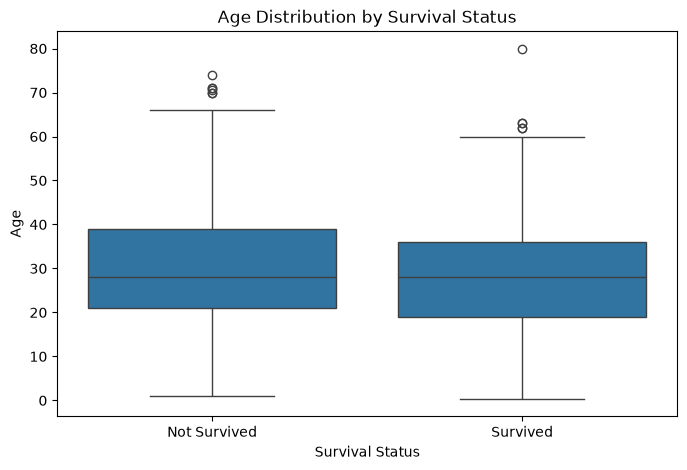

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='survived',
    y='age',
    data=data
)

plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.title("Age Distribution by Survival Status")

plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.show()

In [14]:
t_statistic, p_value = stats.ttest_ind(
    data_survived,
    data_not_survived,
    equal_var=False
)

print("t-statistic = ", t_statistic)
print("p-value = ", p_value)

t-statistic =  -2.0460301043939704
p-value =  0.04118965162586637


In [15]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("There is a statistically significant difference in average age.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("There is no statistically significant difference in average age.")

Reject the Null Hypothesis (H0)
There is a statistically significant difference in average age.


In [16]:
print(f"Mean age of survived passengers =  {data_survived_mean:.2f}")
print(f"Mean age of non-survived passengers = {data_not_survived_mean:.2f}")
print(f"t-statistic = {t_statistic:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Significance level = {alpha}")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a statistically significant difference")
    print("between the average ages of survived and non-survived passengers.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: There is no statistically significant difference")
    print("between the average ages of survived and non-survived passengers.")

Mean age of survived passengers =  28.34
Mean age of non-survived passengers = 30.63
t-statistic = -2.0460
p-value = 0.0412
Significance level = 0.05

Decision: Reject H0
Conclusion: There is a statistically significant difference
between the average ages of survived and non-survived passengers.


In [17]:
fare_data = df[['fare', 'survived']].dropna()

fare_data_survived = fare_data[fare_data['survived'] == 1]['fare']
fare_data_not_survived = fare_data[fare_data['survived'] == 0]['fare']

t_fare, p_fare = stats.ttest_ind(
    fare_data_survived,
    fare_data_not_survived,
    equal_var=False
)

print("t-statistic = ", t_fare)
print("p-value = ", p_fare)

t-statistic =  6.839099259085254
p-value =  2.6993323503141203e-11


In [18]:
alpha = 0.01

if p_fare < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [19]:
contingency_table = pd.crosstab(
    df['sex'],
    df['survived']
)

print(contingency_table)

survived    0    1
sex               
female     81  233
male      468  109


In [20]:
chi2, p_value_chi, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("p-value:", p_value_chi)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of Freedom: 1


In [21]:
alpha = 0.05

if p_value_chi < alpha:
    print("Reject H0")
    print("There is a significant association between sex and survival.")
else:
    print("Fail to Reject H0")
    print("There is no significant association between sex and survival.")

Reject H0
There is a significant association between sex and survival.
